In [1]:
import shapely
import matplotlib.pyplot as plt
import numpy as np
from queue import Queue

# Geometry union (Shapely)

Init primitives.

In [2]:
primitives = {
    'poly1': shapely.geometry.Polygon([(0, 0), (1, 0), (1, 2), (0.8, 2), (0.8, 1), (0, 1)]),
    'poly2': shapely.geometry.Polygon([(0.1, 0), (0.5, 0), (0.5, 0.5), (0.1, 0.5)]),
    'poly3': shapely.geometry.Polygon([(0.6, 0.25), (0.8, 0.25), (0.8, 0.5), (0.6, 0.5)]),
    'poly4': shapely.geometry.Polygon([(0.8, 0.75), (0.9, 0.75), (0.9, 1), (0.8, 1)]),
    'poly5': shapely.geometry.Polygon([(0, 1.25), (0.2, 1.25), (0.2, 1.5), (0, 1.5)]),
    'poly6': shapely.geometry.Polygon([(1.0, 1.0), (1.2, 1.0), (1.2, 1.5), (1.0, 1.5)]),
    'poly7': shapely.geometry.Polygon([(1.0, 2.0), (1.2, 2.0), (1.2, 2.5), (1.0, 2.5)]),
    'poly8': shapely.geometry.Polygon([(0.7, 1.25), (0.9, 1.25), (0.9, 1.5), (0.7, 1.5)]),
    'line1': shapely.geometry.LineString([(0.2, 1.0), (0.5, 1.0)]),
    'line2': shapely.geometry.LineString([(0.8, 0.6), (1.2, 0.6)]),
    'line4': shapely.geometry.LineString([(0.8, 1.2), (1.2, 1.2)]),
    'line5': shapely.geometry.LineString([(0.5, 2.0), (0.6, 2.0)]),
    'line6': shapely.geometry.LineString([(0.6, 2.0), (0.6, 2.5)]),
    'line7': shapely.geometry.LineString([(0.5, 2.5), (0.6, 2.5)]),
    'line8': shapely.geometry.LineString([(0.5, 2.0), (0.5, 2.5)]),
    'line10': shapely.geometry.LineString([(0.6, 0.0), (0.6, -3)]),
    'line11': shapely.geometry.LineString([(0.6, -3), (0.0, -3)]),
    'line12': shapely.geometry.LineString([(0.0, -3), (0.0, 0.0)]),
}

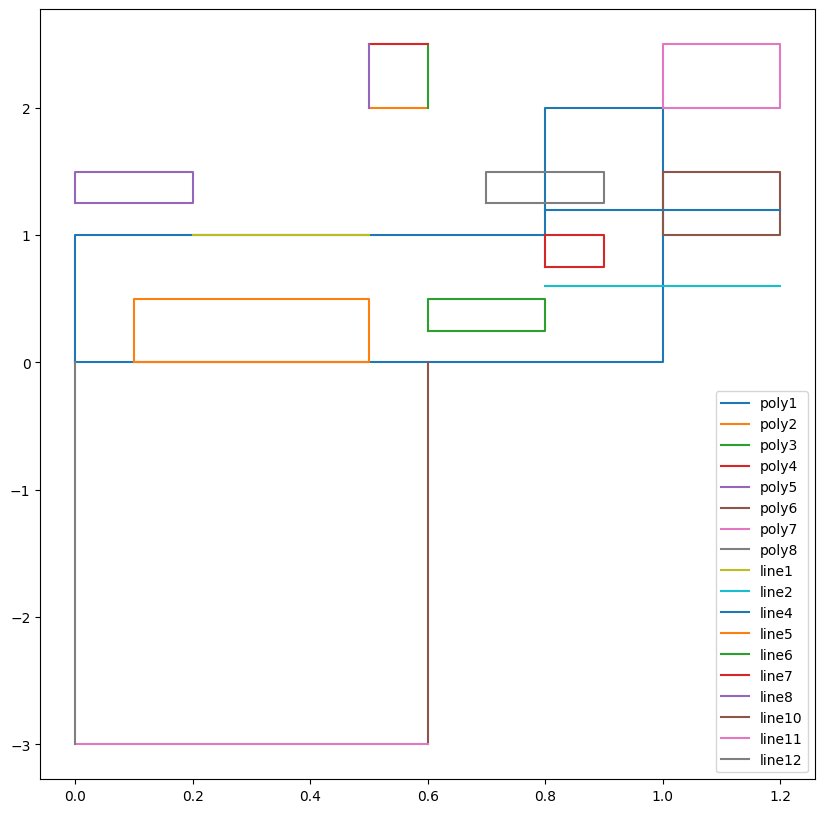

In [3]:
plt.figure(figsize=(10, 10))
for name, prim in primitives.items():
    if type(prim) is shapely.geometry.Polygon:
        plt.plot(*prim.exterior.xy, label=name)
    elif type(prim) is shapely.geometry.LineString:
        plt.plot(*prim.xy, label=name)
plt.legend()
plt.show()

## Union All

In [4]:
primitives_processed = primitives.copy()
for key, value in primitives.items():
        primitives_processed[key] = primitives_processed[key].buffer(1e-9, join_style=2, cap_style=2)

In [5]:
gm = shapely.union_all(list(primitives_processed.values()))

<class 'shapely.geometry.multipolygon.MultiPolygon'>


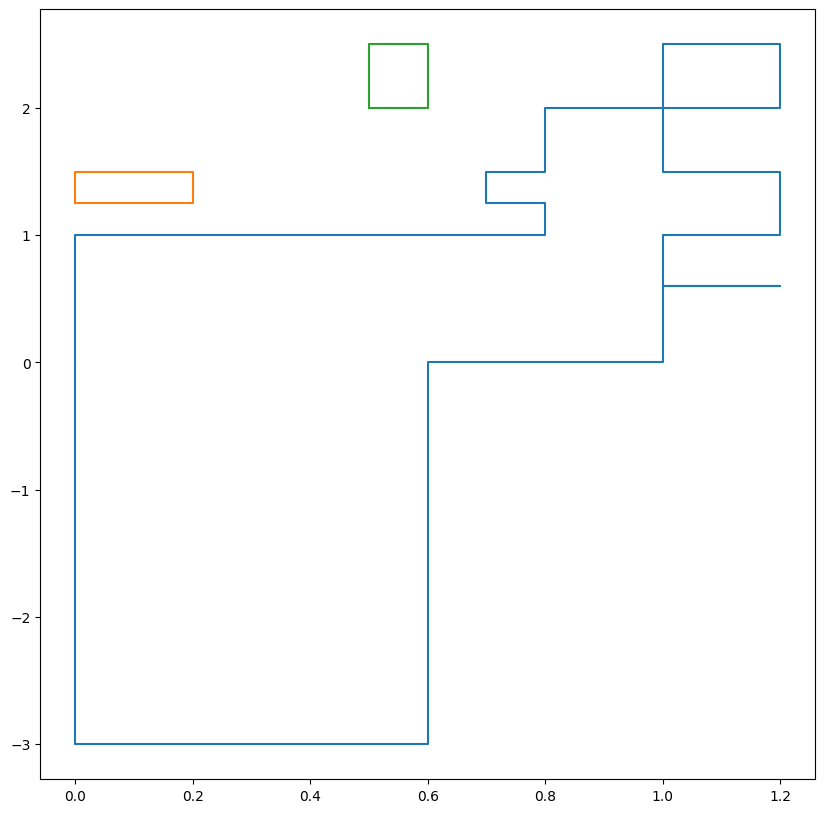

In [6]:
plt.figure(figsize=(10, 10))
if type(gm) is shapely.Polygon:
    plt.plot(*gm.exterior.xy)
else:
    print(type(gm))
    for prim in gm.geoms:
        if type(prim) is shapely.geometry.Polygon:
            plt.plot(*prim.exterior.xy)
        elif type(prim) is shapely.geometry.LineString:
            plt.plot(*prim.xy)
    plt.show()

## Fix broken geometry

Approach 1

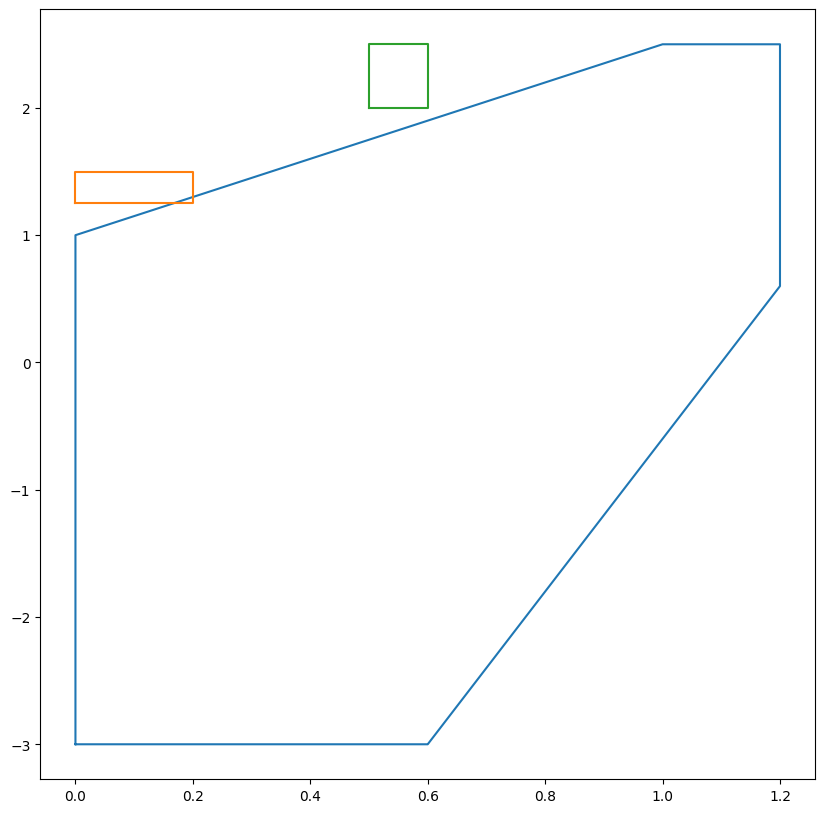

In [7]:
plt.figure(figsize=(10, 10))
if type(gm) is shapely.Polygon:
    plt.plot(*gm.exterior.xy)
else:
    for prim in gm.geoms:
        if type(prim) is shapely.geometry.Polygon:
            convex_hull = shapely.convex_hull(prim)
            convex_hull = convex_hull.buffer(-1e-9, join_style=2, cap_style=2)
            if type(convex_hull) is shapely.geometry.Polygon:
                plt.plot(*convex_hull.exterior.xy)
        elif type(prim) is shapely.geometry.LineString:
            plt.plot(*prim.xy)
        else:
            raise Exception()
    plt.show()

Approach 2

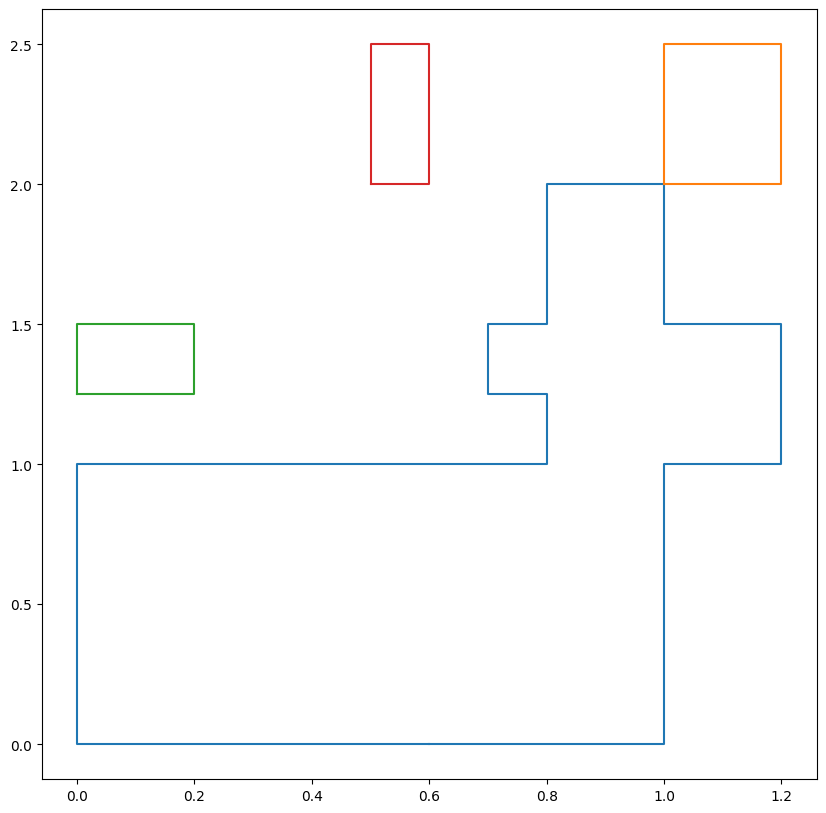

In [8]:
plt.figure(figsize=(10, 10))
if type(gm) is shapely.Polygon:
    plt.plot(*gm.exterior.xy)
else:
    for prim in gm.geoms:
        if type(prim) is shapely.geometry.Polygon:
            if prim.area / prim.envelope.area < 0.01:
                convex_hull = shapely.convex_hull(prim)
                convex_hull = convex_hull.buffer(-1e-9, join_style=2, cap_style=2)
                if type(convex_hull) is shapely.geometry.Polygon:
                    plt.plot(*convex_hull.exterior.xy)
            else:
                prim = prim.buffer(-1e-9, join_style=2, cap_style=2)
                if type(prim) is shapely.geometry.Polygon:
                    plt.plot(*prim.exterior.xy)
                elif type(prim) is shapely.geometry.MultiPolygon:
                    for p in prim.geoms:
                        plt.plot(*p.exterior.xy)
        elif type(prim) is shapely.geometry.LineString:
            plt.plot(*prim.xy)
        else:
            raise Exception()
    plt.show()

`Approach 1` leads to potential zone over-cavering. `Approach 2` leads to potential zone under-cavering. `Approach 1` seems more suitable for our usecase, since there is less chance to miss a marked foreign zone.

# Find all geometry in zone (Ezdxf)

In [9]:
import ezdxf
from ezdxf import select
import sys

In [10]:
try:
    doc = ezdxf.readfile("../data/application_3.dxf")
    # doc = ezdxf.readfile("../data/torgovye_paviliony_field_processed.dxf")
    # doc = ezdxf.readfile("../data/ready_plan.dxf")
    # doc = ezdxf.readfile("../data/kaha.dxf")
except IOError:
    print(f"Not a DXF file or a generic I/O error.")
    sys.exit(1)
except ezdxf.DXFStructureError:
    print(f"Invalid or corrupted DXF file.")
    sys.exit(2)

In [11]:
msp = doc.modelspace()

In [12]:
# window = select.Window((1267097, 102272), (1313306, 44329))
# window = select.Window((1264169, -15000), (1281000, -44000))
# window = select.Window((1386913, 44000), (1435600, -17000))
window = select.Window((0, -70000), (1700000, 160000))

# window = select.Window((0.0, 19000), (80000, 43000))

# window = select.Window((1.1e+7, 3.5e+6), (1.2e+7, 3.8e+6))

# window = select.Window((1.16e+7, 3.45e+6), (1.17e+7, 3.51e+6))

enities = select.bbox_inside(window, msp)

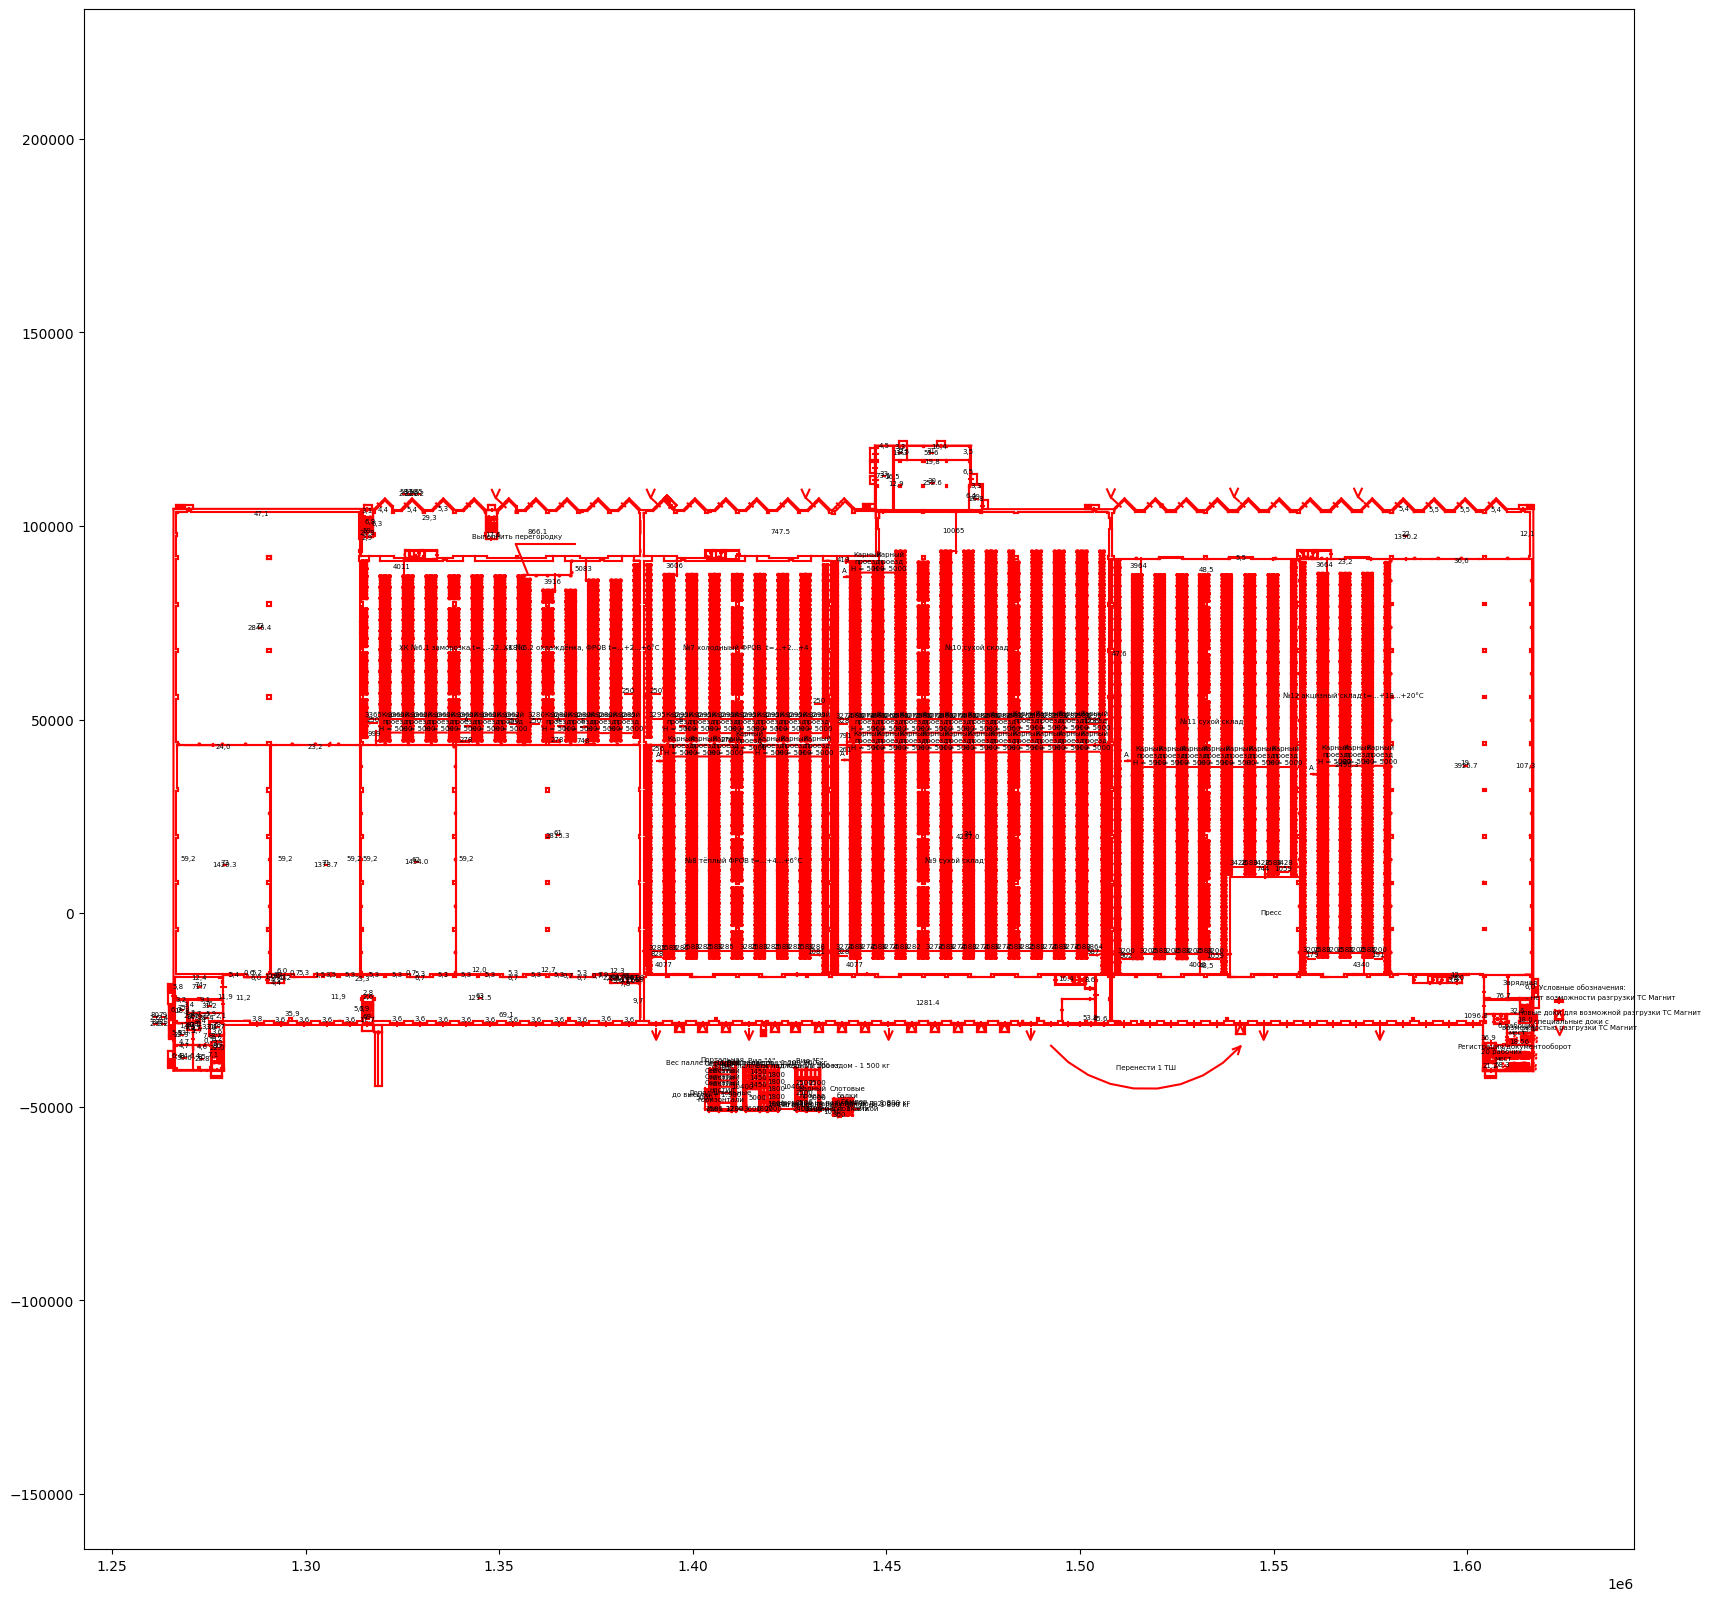

In [13]:
import ezdxf.entities


plt.figure(figsize=(20, 20))
q = Queue()
[q.put(entity) for entity in enities]

while not q.empty():
    entity = q.get()
    if type(entity) is ezdxf.entities.Point:
        for v_entity in entity.virtual_entities():
            q.put(v_entity)
    elif type(entity) is ezdxf.entities.Line:
        plt.plot((entity.dxf.start.x, entity.dxf.end.x), 
                (entity.dxf.start.y, entity.dxf.end.y), 'r-')
    elif type(entity) is ezdxf.entities.LWPolyline:
        x = [point[0] for point in entity.vertices_in_wcs()]
        y = [point[1] for point in entity.vertices_in_wcs()]

        if entity.is_closed:
            x.append(x[0])
            y.append(y[0])

        plt.plot(x, y, 'r-')
    elif type(entity) is ezdxf.entities.MText:
        plt.text(entity.dxf.insert.x, entity.dxf.insert.y, entity.plain_text(), fontsize=5, ha='center')
    elif type(entity) is ezdxf.entities.Text:
        plt.text(entity.dxf.insert.x, entity.dxf.insert.y, entity.plain_text(), fontsize=5, ha='center')
    elif type(entity) is ezdxf.entities.Solid:
        x = [point[0] for point in entity.wcs_vertices(close=True)]
        y = [point[1] for point in entity.wcs_vertices(close=True)]
        plt.plot(x, y, 'r-')
    elif type(entity) is ezdxf.entities.Arc:
        center = entity.ocs().to_wcs(entity.dxf.center)
        radius = entity.dxf.radius
        angles = list(entity.angles(10))
        radians = np.deg2rad(angles)
        x = center[0] + radius * np.cos(radians)
        y = center[1] + radius * np.sin(radians)
        plt.plot(x, y, 'r-')
    elif type(entity) is ezdxf.entities.Circle:
        vertices = list(entity.vertices(np.linspace(0, 360.0, 10)))
        x = [point[0] for point in vertices]
        y = [point[1] for point in vertices]
        plt.plot(x, y, 'r-')
    elif type(entity) is ezdxf.entities.Ellipse:
        vertices = list(entity.vertices(np.linspace(0, 2 * np.pi, 10)))
        x = [point[0] for point in vertices]
        y = [point[1] for point in vertices]
        plt.plot(x, y, 'r-')
    elif type(entity) is ezdxf.entities.Polyline:
        vertices = list(entity.points_in_wcs())
        x = [point[0] for point in vertices]
        y = [point[1] for point in vertices]
        
        if entity.is_closed:
            x.append(x[0])
            y.append(y[0])
        
        plt.plot(x, y, 'r-')
    elif type(entity) is ezdxf.entities.Hatch:
        ocs = entity.ocs()
        for path in entity.paths:
            if type(path) is ezdxf.entities.PolylinePath:
                vertices = path.vertices
                x = [ocs.to_wcs(point)[0] for point in vertices]
                y = [ocs.to_wcs(point)[1] for point in vertices]
                
                if path.is_closed:
                    x.append(x[0])
                    y.append(y[0])
                
                plt.plot(x, y, 'r-')
            elif type(path) is ezdxf.entities.EdgePath:
                for edge in path.edges:
                    if type(edge) is ezdxf.entities.boundary_paths.LineEdge:
                        plt.plot((ocs.to_wcs(edge.start).x,
                                  ocs.to_wcs(edge.end).x), 
                            (ocs.to_wcs(edge.start).y,
                             ocs.to_wcs(edge.end).y), 'r-')
                    elif type(edge) is ezdxf.entities.boundary_paths.ArcEdge:
                        center = ocs.to_wcs(edge.center)
                        radius = edge.radius
                        angles = np.linspace(edge.start_angle, edge.end_angle, 10)
                        radians = np.deg2rad(angles)
                        x = center[0] + radius * np.cos(radians)
                        y = center[1] + radius * np.sin(radians)
                        plt.plot(x, y, 'r-')
    elif type(entity) is ezdxf.entities.Insert:
        for  v_entity in entity.virtual_entities():
            q.put(v_entity)
    elif type(entity) is ezdxf.entities.Dimension:
        for v_entity in entity.virtual_entities():
            q.put(v_entity)
    elif type(entity) is ezdxf.entities.Spline:
        bspline = entity.construction_tool()
        points =[p.xy for p in bspline.approximate(20)]
        x = [point[0] for point in points]
        y = [point[1] for point in points]
        plt.plot(x, y, 'r-')
    elif type(entity) in [ezdxf.entities.mleader.MultiLeader,
                          ezdxf.entities.leader.Leader]:
        pass    
    else:
        print(type(entity))
plt.axis('equal')
print()